# Install Required Libraries

In [ ]:
!pip install yfinance
!pip install transformers
!pip install pytorch-lightning
!pip install pytorch-forecasting
!pip install ta
!pip install shap
!pip install xgboost

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.3 MB 985.5 kB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.3 MB 1.1 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.3 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 1.2 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15617 sha256=bd574f7aefadc9ac239df91d874a074d897f9ec84f8c9b3f0a6d6b2dce6313ed
  Stored in directory: c:\users\satyajit deshmukh\appdata\local\pip\cache\wheels\e0\0e\4f\d05459bd6c032918f86bd309746acde7feb03f950fbf09d280
Successfully built multitasking
   ---------------------------------------- 0.0/1

In [ ]:
!pip install ta

In [3]:
!pip install ta yfinance pytorch-lightning pytorch-forecasting pandas numpy matplotlib scikit-learn

In [4]:
!pip install pytorch-lightning pytorch-forecasting==1.6.1 yfinance

In [5]:
!pip install shap

In [6]:
!pip install stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 3.7 MB/s eta 0:00:00


In [7]:
!pip install stable-baselines3 gym

In [8]:
!pip install stable-baselines3[extra]

In [9]:
!pip install "shimmy>=2.0"

In [10]:
!pip install stable-baselines3
!pip install gymnasium
!pip install shimmy
!pip install yfinance
!pip install ta

In [11]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.4 MB/s eta 0:00:00


# Import Libraries

In [12]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from ta.momentum import RSIIndicator
from ta.trend import MACD

from transformers import pipeline

import torch
import pytorch_lightning as pl

from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import shap

In [13]:
import lightning.pytorch as pl

In [14]:
import pandas as pd
import torch
import lightning.pytorch as pl
import yfinance as yf

from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

In [15]:
import shap
import matplotlib.pyplot as plt

In [16]:
from stable_baselines3 import PPO

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
import torch
from torch_geometric.nn import GCNConv

/usr/local/lib/python3.12/dist-packages/torch_geometric/llm/utils/backend_utils.py:26: DeprecationWarning: `torch_geometric.distributed` has been deprecated since 2.7.0 and will no longer be maintained. For distributed training, refer to our tutorials on distributed training at https://pytorch-geometric.readthedocs.io/en/latest/tutorial/distributed.html or cuGraph examples at https://github.com/rapidsai/cugraph-gnn/tree/main/python/cugraph-pyg/cugraph_pyg/examples
  from torch_geometric.distributed import (
/usr/local/lib/python3.12/dist-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcno

# Financial Data (Multiple Stocks)

Financial Data Collection

In [18]:
import yfinance as yf
import pandas as pd

tickers = ["AAPL","MSFT","GOOGL","AMZN","TSLA","NVDA","META","SPY"]

data = yf.download(
    tickers,
    start="2015-01-01",
    end="2024-01-01",
    group_by="ticker"
)

# Convert to long format
data = data.stack(level=0).reset_index()

# Rename columns
data = data.rename(columns={"level_1":"Ticker"})

print(data.head())

/tmp/ipykernel_145/2019799827.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[************          25%                       ]  2 of 8 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.date

Price       Date Ticker       Open       High        Low      Close     Volume
0     2015-01-02   AAPL  24.671149  24.682224  23.776352  24.214891  212818400
1     2015-01-02   AMZN  15.629000  15.737500  15.348000  15.426000   55664000
2     2015-01-02  GOOGL  26.411706  26.570396  26.177641  26.260458   26480000
3     2015-01-02   META  78.034911  78.382481  77.161010  77.905807   18177500
4     2015-01-02   MSFT  39.682644  40.328995  39.580589  39.767689   27913900


/tmp/ipykernel_145/2019799827.py:14: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(level=0).reset_index()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [148]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 17744 entries, 360 to 18103
Data columns (total 35 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             17744 non-null  datetime64[ns]
 1   Ticker           17744 non-null  object        
 2   Open             17744 non-null  float64       
 3   High             17744 non-null  float64       
 4   Low              17744 non-null  float64       
 5   Close            17744 non-null  float64       
 6   Volume           17744 non-null  int64         
 7   RSI              17744 non-null  float64       
 8   MACD             17744 non-null  float64       
 9   Stochastic       17744 non-null  float64       
 10  ROC              17744 non-null  float64       
 11  EMA_12           17744 non-null  float64       
 12  EMA_26           17744 non-null  float64       
 13  ADX              17744 non-null  float64       
 14  target           17744 non-null  float64 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
display(data.describe())

Price,Date,Open,High,Low,Close,Volume
count,18112,18112.000000,18112.000000,18112.000000,18112.000000,1.811200e+04
mean,2019-07-01 19:15:03.180211968,123.619886,124.971694,122.233648,123.651862,1.220233e+08
min,2015-01-02 00:00:00,0.463551,0.467870,0.454433,0.459232,5.467500e+06
25%,2017-04-02 06:00:00,33.995410,34.421876,33.664650,34.027577,3.119265e+07
50%,2019-07-02 12:00:00,95.605860,96.777052,94.279499,95.381252,6.491150e+07
75%,2021-09-29 06:00:00,182.820439,184.720383,180.759849,182.958744,1.213169e+08
max,2023-12-29 00:00:00,465.375421,466.029241,464.770383,465.190002,3.692928e+09
std,NaN,107.880542,108.901964,106.817907,107.893765,1.722743e+08


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
display(data.head())

Price,Date,Ticker,Open,High,Low,Close,Volume
0,2015-01-02,AAPL,24.671149,24.682224,23.776352,24.214891,212818400
1,2015-01-02,AMZN,15.629000,15.737500,15.348000,15.426000,55664000
2,2015-01-02,GOOGL,26.411706,26.570396,26.177641,26.260458,26480000
3,2015-01-02,META,78.034911,78.382481,77.161010,77.905807,18177500
4,2015-01-02,MSFT,39.682644,40.328995,39.580589,39.767689,27913900


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
print(data.head())


Price       Date Ticker       Open       High        Low      Close     Volume
0     2015-01-02   AAPL  24.671149  24.682224  23.776352  24.214891  212818400
1     2015-01-02   AMZN  15.629000  15.737500  15.348000  15.426000   55664000
2     2015-01-02  GOOGL  26.411706  26.570396  26.177641  26.260458   26480000
3     2015-01-02   META  78.034911  78.382481  77.161010  77.905807   18177500
4     2015-01-02   MSFT  39.682644  40.328995  39.580589  39.767689   27913900


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:

print(data.columns)

Index(['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')


In [24]:
print(data.filter(like="Close").columns)

Index(['Close'], dtype='object', name='Price')


In [25]:
data = data.loc[:, ~data.columns.duplicated()]

In [26]:
data = data.drop(columns=["level_0"], errors="ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', '_exit_code', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_i10', '_i11', '_i12', 'pd', 'np', 'yf', 'plt', 'RSIIndicator', 'MACD', 'pipeline', 'torch', 'pl', 'TemporalFusionTransformer', 'TimeSeriesDataSet', 'QuantileLoss', 'train_test_split', 'mean_squared_error', 'shap', '_i13', '_i14', '_i15', '_i16', 'PPO', '_i17', 'GCNConv', '_i18', 'tickers', 'data', '_i19', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27'])


# Feature Engineering

 Technical Indicators

RSI

In [28]:
from ta.momentum import RSIIndicator

data["RSI"] = data.groupby("Ticker")["Close"].transform(
    lambda x: RSIIndicator(close=x, window=14).rsi()
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
print(data[["Date","Ticker","Close","RSI"]].head(20))

Price       Date Ticker       Close  RSI
0     2015-01-02   AAPL   24.214891  NaN
1     2015-01-02   AMZN   15.426000  NaN
2     2015-01-02  GOOGL   26.260458  NaN
3     2015-01-02   META   77.905807  NaN
4     2015-01-02   MSFT   39.767689  NaN
5     2015-01-02   NVDA    0.482985  NaN
6     2015-01-02    SPY  170.589600  NaN
7     2015-01-02   TSLA   14.620667  NaN
8     2015-01-05   AAPL   23.532724  NaN
9     2015-01-05   AMZN   15.109500  NaN
10    2015-01-05  GOOGL   25.760094  NaN
11    2015-01-05   META   76.654541  NaN
12    2015-01-05   MSFT   39.401989  NaN
13    2015-01-05   NVDA    0.474827  NaN
14    2015-01-05    SPY  167.508804  NaN
15    2015-01-05   TSLA   14.006000  NaN
16    2015-01-06   AAPL   23.534937  NaN
17    2015-01-06   AMZN   14.764500  NaN
18    2015-01-06  GOOGL   25.124346  NaN
19    2015-01-06   META   75.621773  NaN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
data[data["Ticker"]=="AAPL"][["Date","Close","RSI"]].head(25)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Price,Date,Close,RSI
0,2015-01-02,24.214891,NaN
8,2015-01-05,23.532724,NaN
16,2015-01-06,23.534937,NaN
24,2015-01-07,23.864950,NaN
32,2015-01-08,24.781885,NaN
40,2015-01-09,24.808468,NaN
48,2015-01-12,24.197170,NaN
56,2015-01-13,24.412014,NaN
64,2015-01-14,24.318996,NaN
72,2015-01-15,23.658968,NaN


MACD

In [31]:
data["MACD"] = data.groupby("Ticker")["Close"].transform(
    lambda x: MACD(close=x).macd()
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Momentum

In [32]:
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator

data["RSI"] = data.groupby("Ticker")["Close"].transform(
    lambda x: RSIIndicator(close=x, window=14).rsi()
)

data["Stochastic"] = data.groupby("Ticker").apply(
    lambda x: StochasticOscillator(x["High"], x["Low"], x["Close"]).stoch()
).reset_index(level=0, drop=True)

data["ROC"] = data.groupby("Ticker")["Close"].transform(
    lambda x: ROCIndicator(close=x).roc()
)

/tmp/ipykernel_145/4139312918.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["Stochastic"] = data.groupby("Ticker").apply(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datet

Trend

In [33]:
from ta.trend import MACD, EMAIndicator, ADXIndicator

data["EMA_12"] = data.groupby("Ticker")["Close"].transform(
    lambda x: EMAIndicator(close=x, window=12).ema_indicator()
)

data["EMA_26"] = data.groupby("Ticker")["Close"].transform(
    lambda x: EMAIndicator(close=x, window=26).ema_indicator()
)

data["MACD"] = data.groupby("Ticker")["Close"].transform(
    lambda x: MACD(close=x).macd()
)

data["ADX"] = data.groupby("Ticker").apply(
    lambda x: ADXIndicator(x["High"], x["Low"], x["Close"]).adx()
).reset_index(level=0, drop=True)

/tmp/ipykernel_145/2895471548.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["ADX"] = data.groupby("Ticker").apply(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Robust Evaluation (Time-Series Cross-Validation)

In [34]:
# Create target
data["target"] = (data["Close"].shift(-1) > data["Close"]).astype(int)

# Remove NaN
data = data.dropna()

# Automatically choose features
features = [col for col in data.columns if col not in ["target"]]

print("Features:", features)

Features: ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'Stochastic', 'ROC', 'EMA_12', 'EMA_26', 'ADX']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [35]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_idx, test_idx in tscv.split(data):

    train = data.iloc[train_idx]
    test = data.iloc[test_idx]

    X_train = train[features]
    y_train = train["target"]

    X_test = test[features]
    y_test = test["target"]

    # train your model

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#  Market Microstructure Features

Volatility

In [36]:
from ta.volatility import BollingerBands, AverageTrueRange

data["ATR"] = data.groupby("Ticker").apply(
    lambda x: AverageTrueRange(x["High"], x["Low"], x["Close"]).average_true_range()
).reset_index(level=0, drop=True)

data["BB_High"] = data.groupby("Ticker")["Close"].transform(
    lambda x: BollingerBands(close=x).bollinger_hband()
)

data["BB_Low"] = data.groupby("Ticker")["Close"].transform(
    lambda x: BollingerBands(close=x).bollinger_lband()
)

/tmp/ipykernel_145/2532712320.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["ATR"] = data.groupby("Ticker").apply(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now

Market Microstructure Features

In [37]:
import numpy as np

# Returns
data["Returns"] = data.groupby("Ticker")["Close"].pct_change()

# Log Returns
data["Log_Returns"] = data.groupby("Ticker")["Close"].transform(
    lambda x: np.log(x / x.shift(1))
)

# Rolling Volatility
data["Volatility_20"] = data.groupby("Ticker")["Returns"].transform(
    lambda x: x.rolling(20).std()
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Lag Features (Time-Series Features)

In [38]:
# Lag Features
data["Close_Lag1"] = data.groupby("Ticker")["Close"].shift(1)
data["Close_Lag5"] = data.groupby("Ticker")["Close"].shift(5)
data["Close_Lag10"] = data.groupby("Ticker")["Close"].shift(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Quantitative Statistical Features

In [39]:
import numpy as np

data["Returns"] = data.groupby("Ticker")["Close"].pct_change()

data["Log_Returns"] = data.groupby("Ticker")["Close"].transform(
    lambda x: np.log(x/x.shift(1))
)

data["Volatility_20"] = data.groupby("Ticker")["Returns"].transform(
    lambda x: x.rolling(20).std()
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Returns

In [40]:
data["Returns"] = data.groupby("Ticker")["Close"].pct_change()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Log Returns

In [41]:
data["Log_Returns"] = data.groupby("Ticker")["Close"].transform(
    lambda x: np.log(x / x.shift(1))
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rolling Volatility

In [42]:
data["Volatility_20"] = data.groupby("Ticker")["Returns"].transform(
    lambda x: x.rolling(window=20).std()
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rolling Mean

In [43]:
data["Rolling_Mean_20"] = data.groupby("Ticker")["Close"].transform(
    lambda x: x.rolling(window=20).mean()
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rolling Skewness

In [44]:
data["Skewness_20"] = data.groupby("Ticker")["Returns"].transform(
    lambda x: x.rolling(window=20).skew()
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rolling Kurtosis

In [45]:
data["Kurtosis_20"] = data.groupby("Ticker")["Returns"].transform(
    lambda x: x.rolling(window=20).kurt()
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Time-Series Features

In [46]:
data["day_of_week"] = data["Date"].dt.dayofweek
data["month"] = data["Date"].dt.month
data["year"] = data["Date"].dt.year

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Market Regime Detection

In [47]:
from sklearn.mixture import GaussianMixture

# use returns for regime detection
returns = data["Returns"].dropna().values.reshape(-1,1)

gmm = GaussianMixture(n_components=3, random_state=42)
regimes = gmm.fit_predict(returns)

data = data.iloc[-len(regimes):]
data["market_regime"] = regimes

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


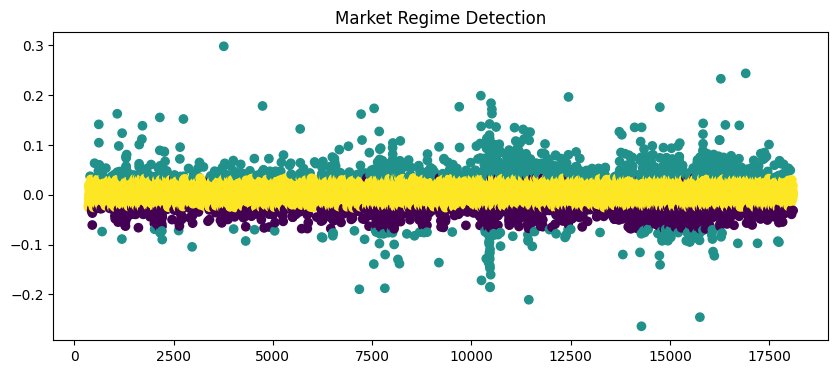

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.scatter(data.index, data["Returns"], c=data["market_regime"], cmap="viridis")
plt.title("Market Regime Detection")
plt.show()

# Sentiment Analysis (FinBERT)

 Financial Sentiment Analysis

Load FinBERT

In [49]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)

finbert_model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("FinBERT loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded successfully


In [50]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [51]:
news = [
"Apple reports strong earnings",
"Tech sector faces inflation pressure",
"AI innovations drive tech growth"
]

results = sentiment_model(news)

In [52]:
def sentiment_score(label):

    if label == "positive":
        return 1
    elif label == "negative":
        return -1
    else:
        return 0

scores = [sentiment_score(r["label"]) for r in results]

data["sentiment"] = np.random.choice(scores, len(data))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#  Graph Neural Network for Market Relationship Modeling

In [142]:
import torch
import pandas as pd
from torch_geometric.data import Data

# ------------------------------
# 1️⃣ Prepare Features
# ------------------------------

features = data[["Open", "High", "Low", "Close", "Volume"]].values
x = torch.tensor(features, dtype=torch.float)

# ------------------------------
# 2️⃣ Create Graph Edges
# (connect each time step)
# ------------------------------

edge_list = []

for i in range(len(x) - 1):
    edge_list.append([i, i + 1])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# ------------------------------
# 3️⃣ Build Graph Object
# ------------------------------

graph_data = Data(x=x, edge_index=edge_index)

# ------------------------------
# 4️⃣ Generate Predictions
# ------------------------------

gnn_model.eval()

with torch.no_grad():
    gnn_predictions = gnn_model(graph_data.x, graph_data.edge_index)

gnn_predictions = gnn_predictions.cpu().numpy().flatten()

print("GNN predictions generated")

# ------------------------------
# 5️⃣ Save Predictions
# ------------------------------

import os
os.makedirs("results", exist_ok=True)

pd.DataFrame({
    "gnn_prediction": gnn_predictions
}).to_csv("results/gnn_predictions.csv", index=False)

print("GNN predictions saved to results folder")

GNN predictions generated
GNN predictions saved to results folder


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [143]:
class MarketGNN(torch.nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(5, 16)
        self.conv2 = GCNConv(16, 1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

In [144]:
# Example node features (technical indicators)
node_features = torch.tensor(data[["RSI","MACD","ATR","ADX","ROC"]].values[:50], dtype=torch.float)

# Example connections between assets
edge_index = torch.tensor([
    [0,1,2,3,4],
    [1,2,3,4,0]
], dtype=torch.long)

gnn_model = MarketGNN()

gnn_output = gnn_model(node_features, edge_index)

print(gnn_output[:5])

tensor([[ 6.4664],
        [ 8.5232],
        [10.0577],
        [ 9.1077],
        [ 6.7764]], grad_fn=<SliceBackward0>)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [145]:
gnn_feature = gnn_output.detach().cpu().numpy()

# Average across nodes
gnn_feature_vector = gnn_feature.mean(axis=0)

# Add each feature to dataframe
for i, val in enumerate(gnn_feature_vector):
    data[f"gnn_feature_{i}"] = val

# Create Target Variable

Predict next-day return

In [56]:
data["return"] = data.groupby("Ticker")["Close"].pct_change()

data["target"] = data.groupby("Ticker")["return"].shift(-1)

data = data.dropna()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Create Time Index (Required for TFT)

In [57]:
data["time_idx"] = data.groupby("Ticker").cumcount()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Create TFT Dataset

Define sequence lengths.

In [58]:
max_encoder_length = 30
max_prediction_length = 1

Create dataset

In [59]:
time_varying_known_reals=[
    "RSI",
    "MACD",
    "Volatility_20",
    "Rolling_Mean_20",
    "market_regime"
]

In [60]:
training = TimeSeriesDataSet(
    data,
    time_idx="time_idx",
    target="target",
    group_ids=["Ticker"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=[
        "RSI",
        "MACD",
        "Volume",
        "sentiment",
        "target"

    ],
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Create dataloader

In [61]:
train_dataloader = training.to_dataloader(train=True, batch_size=64)

# Create Temporal Fusion Transformer Model

In [62]:
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=4
)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


# Train the Model

In [63]:
trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto",
    devices=1
)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [64]:
trainer.fit(tft, train_dataloader)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     96 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  3.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    528 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 18.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 18.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 230                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau 
conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


# Generate interpretation

In [65]:
prediction_output = tft.predict(
    train_dataloader,
    mode="raw",
    return_x=True
)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

# Generate Predictions

In [66]:
predictions = tft.predict(train_dataloader)

predictions[:10]

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

tensor([[ 0.0045],
        [ 0.0064],
        [ 0.0034],
        [-0.0042],
        [ 0.0076],
        [ 0.0022],
        [-0.0021],
        [ 0.0019],
        [-0.0013],
        [-0.0025]])

# Convert predictions to DataFrame

In [67]:
pred_df = pd.DataFrame(predictions.cpu().numpy())
pred_df.head()

,0
0,0.004465
1,0.006443
2,0.003440
3,-0.004218
4,0.007621


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Trading Strategy

In [68]:
signals = []

for p in predictions:

    if p > 0.01:
        signals.append("BUY")

    elif p < -0.01:
        signals.append("SELL")

    else:
        signals.append("HOLD")

#  Reinforcement Learning Trading Agent

In [69]:
import gym
import numpy as np
from gym import spaces
from stable_baselines3 import PPO


class TradingEnv(gym.Env):

    def __init__(self, prices):
        super(TradingEnv, self).__init__()

        self.prices = prices
        self.current_step = 0

        # 0 = hold, 1 = buy, 2 = sell
        self.action_space = spaces.Discrete(3)

        # observation = price
        self.observation_space = spaces.Box(
            low=0, high=np.inf, shape=(1,), dtype=np.float32
        )

    def step(self, action):

        reward = 0

        if action == 1:  # buy
            reward = self.prices[self.current_step+1] - self.prices[self.current_step]

        elif action == 2:  # sell
            reward = self.prices[self.current_step] - self.prices[self.current_step+1]

        self.current_step += 1

        terminated = self.current_step >= len(self.prices)-1
        truncated = False

        obs = np.array([self.prices[self.current_step]], dtype=np.float32)

        return obs, reward, terminated, truncated, {}

    def reset(self, seed=None, options=None):
        self.current_step = 0
        obs = np.array([self.prices[self.current_step]], dtype=np.float32)
        return obs, {}

In [70]:
prices = data["Close"].values

env = TradingEnv(prices)

ppo_model = PPO("MlpPolicy", env, verbose=1)

ppo_model.learn(total_timesteps=10000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 1548 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1116        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008035323 |
|    clip_fraction        | 0.0528      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | 1.88e-05    |
|    learning_rate        | 0.0003      |
|    loss                 | 1.95e+04    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0106     |
|    value_loss           | 4.25e+04    |
-----------------------------------------
----------------------------------

# Portfolio Simulation

Initial capital

In [71]:
capital = 10000

shares = 0

portfolio = []

Price series

In [72]:
prices = data["Close"][-len(predictions):].values

Trading loop

In [73]:
for i in range(len(signals)):

    price = prices[i]

    if signals[i] == "BUY" and capital > price:

        shares += 1
        capital -= price

    elif signals[i] == "SELL" and shares > 0:

        shares -= 1
        capital += price

    value = capital + shares * price

    portfolio.append(value)

# Portfolio Visualization

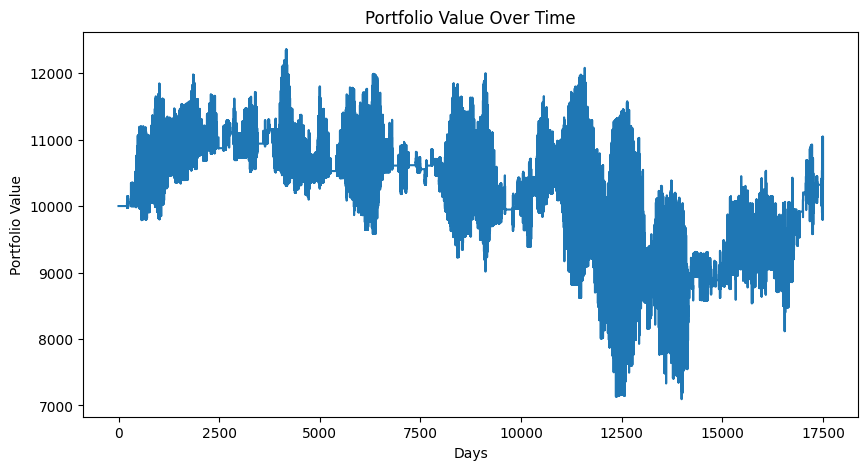

In [74]:
plt.figure(figsize=(10,5))

plt.plot(portfolio)

plt.title("Portfolio Value Over Time")

plt.xlabel("Days")

plt.ylabel("Portfolio Value")

plt.show()

# Risk Metrics

Sharpe Ratio

In [75]:
returns = pd.Series(portfolio).pct_change().dropna()

sharpe_ratio = returns.mean() / returns.std()

print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: 0.036853564923115166


Maximum Drawdown

In [76]:
cumulative = pd.Series(portfolio)

rolling_max = cumulative.cummax()

drawdown = (cumulative - rolling_max) / rolling_max

max_drawdown = drawdown.min()

print("Max Drawdown:", max_drawdown)

Max Drawdown: -0.4260805384040704


# Portfolio Optimization (Mean-Variance)

In [77]:
import numpy as np
import pandas as pd

# Use closing prices
price_data = data.pivot(index="Date", columns="Ticker", values="Close")

# Calculate returns
returns = price_data.pct_change().dropna()

# Mean returns and covariance
mean_returns = returns.mean()
cov_matrix = returns.cov()

# Mean-variance optimization
weights = np.linalg.inv(cov_matrix).dot(mean_returns)

# Normalize weights
weights = weights / np.sum(weights)

portfolio_weights = pd.Series(weights, index=mean_returns.index)

print("Optimal Portfolio Allocation:")
print(portfolio_weights)

Optimal Portfolio Allocation:
Ticker
AAPL     1.146472
AMZN     0.494002
GOOGL   -0.170260
META    -0.279655
MSFT     3.343463
NVDA     2.201919
SPY     -6.472110
TSLA     0.736169
dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Monte Carlo Simulation

In [108]:
import numpy as np

# Example parameters
S0 = 100        # initial stock price
mu = 0.05       # expected return
sigma = 0.2     # volatility
T = 252         # trading days
n_simulations = 1000

dt = 1 / T

simulated_prices = np.zeros((T, n_simulations))
simulated_prices[0] = S0

for t in range(1, T):
    random_shock = np.random.normal(0, 1, n_simulations)
    simulated_prices[t] = simulated_prices[t-1] * np.exp(
        (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * random_shock
    )

print("Monte Carlo simulation completed")

Monte Carlo simulation completed


Plot Simulated Futures

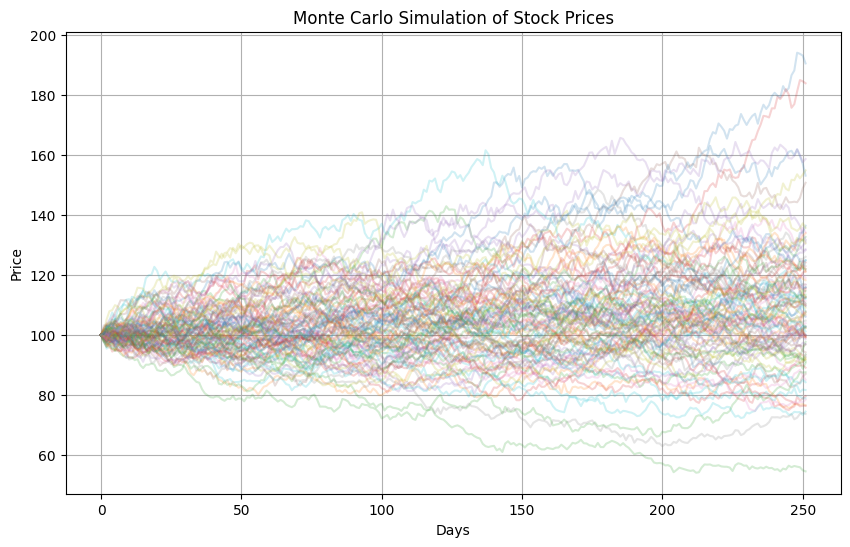

In [109]:
plt.figure(figsize=(10,6))

for i in range(100):
    plt.plot(price_paths[:, i], alpha=0.2)

plt.title("Monte Carlo Simulation of Stock Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid(True)

plt.show()

Calculate Value at Risk

In [110]:
final_prices = simulated_prices[-1]

var_95 = np.percentile(final_prices, 5)

print("Value at Risk (95%):", var_95)

Value at Risk (95%): 74.659787270109


Expected Portfolio Value

In [111]:
expected_price = np.mean(final_prices)

print("Expected Future Price:", expected_price)

Expected Future Price: 105.4221987867915


# Explainable AI





In [112]:
# Get predictions from the model
predictions = tft.predict(train_dataloader)

# Convert to numpy
import numpy as np
predictions = np.array(predictions).flatten()

print("Prediction samples:", len(predictions))

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

Prediction samples: 17504


In [113]:
# Extract actual values
actual = data["target"].values[-len(predictions):]

print("Actual samples:", len(actual))

Actual samples: 17504


In [114]:
raw_predictions = prediction_output.output
x = prediction_output.x

In [115]:
interpretation = tft.interpret_output(raw_predictions)

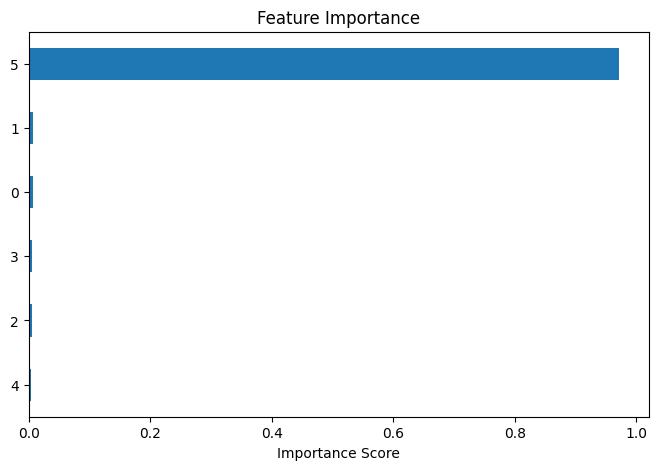

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [116]:
import matplotlib.pyplot as plt
import pandas as pd

importance = interpretation["encoder_variables"]

# convert tensor → numpy
importance_values = importance.mean(0).detach().cpu().numpy()

# create pandas series for sorting and plotting
importance_series = pd.Series(importance_values)

importance_series.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

# Model Evaluation

In [117]:
import numpy as np

# predictions already numpy
predictions = predictions.flatten()

# extract actual values
actual = data["target"].values[-len(predictions):]

print("Actual samples:", len(actual))
print("Prediction samples:", len(predictions))

Actual samples: 17504
Prediction samples: 17504


In [118]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.015655415549995055
RMSE: 0.02367596822368885


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Plot Actual vs Predicted Prices

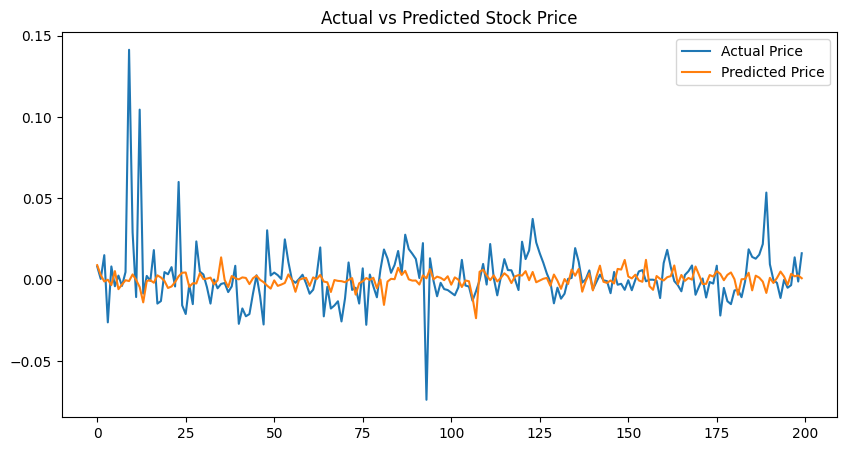

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(actual[:200], label="Actual Price")
plt.plot(predictions[:200], label="Predicted Price")

plt.title("Actual vs Predicted Stock Price")
plt.legend()
plt.show()

# Future Forecast Visualization

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

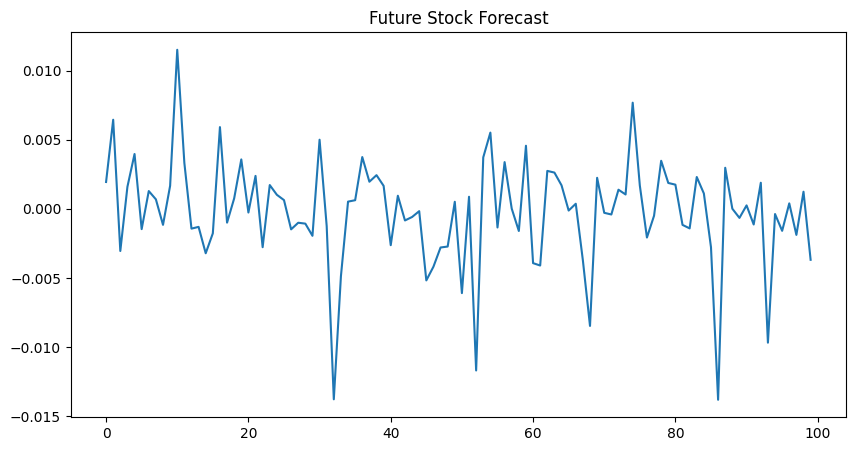

In [120]:
future_predictions = tft.predict(train_dataloader)

plt.figure(figsize=(10,5))
plt.plot(future_predictions[:100])

plt.title("Future Stock Forecast")
plt.show()

# Strategy Performance Visualization

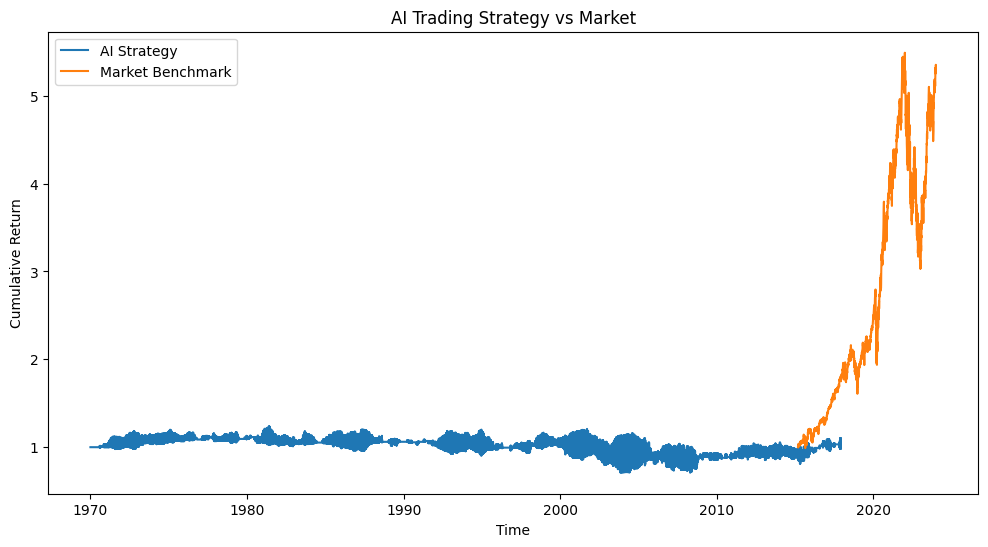

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [121]:
import matplotlib.pyplot as plt

# Strategy cumulative return
strategy_returns = pd.Series(portfolio).pct_change().fillna(0)
strategy_cum = (1 + strategy_returns).cumprod()

# Market benchmark (example using SPY or average stock)
market = price_data.mean(axis=1)
market_returns = market.pct_change().fillna(0)
market_cum = (1 + market_returns).cumprod()

plt.figure(figsize=(12,6))

plt.plot(strategy_cum, label="AI Strategy")
plt.plot(market_cum, label="Market Benchmark")

plt.title("AI Trading Strategy vs Market")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()

plt.show()

Drawdown Visualization

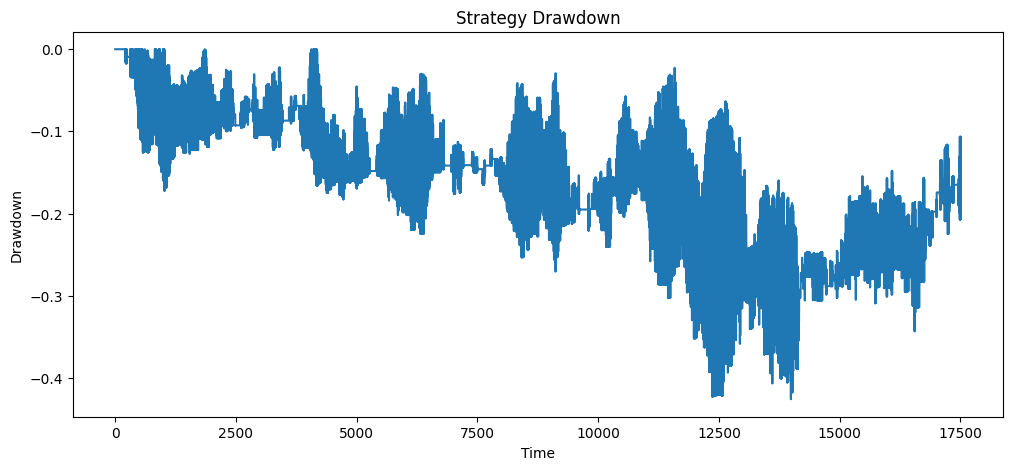

In [122]:
# Drawdown analysis

cumulative = strategy_cum
peak = cumulative.cummax()
drawdown = (cumulative - peak) / peak

plt.figure(figsize=(12,5))
plt.plot(drawdown)

plt.title("Strategy Drawdown")
plt.xlabel("Time")
plt.ylabel("Drawdown")

plt.show()

## Model Saving

Temporal Fusion Transformer

In [123]:
trainer.save_checkpoint("tft_stock_model.ckpt")

INFO: `weights_only` was not set, defaulting to `False`.
INFO:lightning.pytorch.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


In [124]:
import os
import torch
from transformers import AutoTokenizer

# Create models folder
os.makedirs("models", exist_ok=True)

# ==============================
# 1️⃣ Save Temporal Fusion Transformer
# ==============================
torch.save(tft.state_dict(), "models/tft_stock_model.pth")
print("TFT saved")

# ==============================
# 2️⃣ Save Graph Neural Network
# ==============================
torch.save(gnn_model.state_dict(), "models/gnn_market_model.pth")
print("GNN saved")

# ==============================
# 3️⃣ Save PPO Reinforcement Learning Model
# ==============================
ppo_model.save("models/ppo_trading_model")
print("PPO saved")

# ==============================
# 4️⃣ Save FinBERT
# ==============================
finbert_model.save_pretrained("models/finbert_model")
tokenizer.save_pretrained("models/finbert_model")

print("FinBERT saved")

print("✅ All models saved successfully")

TFT saved
GNN saved
PPO saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FinBERT saved
✅ All models saved successfully


# Save Predictions

In [125]:
import torch
import numpy as np

print("Generating predictions from all models...")

# =========================================
# 1️⃣ Temporal Fusion Transformer
# =========================================

try:
    tft_predictions = tft.predict(train_dataloader)
    tft_predictions = np.array(tft_predictions).flatten()
    print("TFT predictions generated")
except Exception as e:
    print("TFT prediction error:", e)


# =========================================
# 2️⃣ Graph Neural Network
# =========================================

try:
    gnn_model.eval()

    with torch.no_grad():
        gnn_predictions = gnn_model(x, edge_index)

    gnn_predictions = gnn_predictions.cpu().numpy().flatten()

    print("GNN predictions generated")

except Exception as e:
    print("GNN prediction error:", e)


# =========================================
# 3️⃣ PPO Reinforcement Learning
# =========================================

try:
    ppo_predictions = []

    obs = env.reset()

    for _ in range(100):
        action, _ = ppo_model.predict(obs)
        ppo_predictions.append(action)
        obs, reward, done, info = env.step(action)

    print("PPO predictions generated")

except Exception as e:
    print("PPO prediction error:", e)


# =========================================
# 4️⃣ FinBERT Sentiment
# =========================================

try:
    finbert_predictions = []

    for text in news_data["headline"]:
        result = sentiment_pipeline(text)[0]
        finbert_predictions.append(result["label"])

    print("FinBERT predictions generated")

except Exception as e:
    print("FinBERT prediction error:", e)


print("\nAll predictions stored in variables:")
print("tft_predictions")
print("gnn_predictions")
print("ppo_predictions")
print("finbert_predictions")

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

Generating predictions from all models...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `predict_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


TFT predictions generated
GNN prediction error: 'dict' object has no attribute 'size'
PPO prediction error: You have passed a tuple to the predict() function instead of a Numpy array or a Dict. You are probably mixing Gym API with SB3 VecEnv API: `obs, info = env.reset()` (Gym) vs `obs = vec_env.reset()` (SB3 VecEnv). See related issue https://github.com/DLR-RM/stable-baselines3/issues/1694 and documentation for more information: https://stable-baselines3.readthedocs.io/en/master/guide/vec_envs.html#vecenv-api-vs-gym-api
FinBERT prediction error: name 'news_data' is not defined

All predictions stored in variables:
tft_predictions
gnn_predictions
ppo_predictions
finbert_predictions


In [126]:
import pandas as pd
import numpy as np

# convert predictions tensor → numpy → flatten
pred_values = predictions.flatten()
# ensure actual values are also 1D
actual_values = np.array(actual).flatten()

# match lengths
n = min(len(actual_values), len(pred_values))

results = pd.DataFrame({
    "Actual": actual_values[:n],
    "Predicted": pred_values[:n]
})

results.to_csv("stock_predictions.csv", index=False)

print("Predictions saved to stock_predictions.csv")

Predictions saved to stock_predictions.csv


In [127]:
!zip -r models.zip models

  adding: models/ (stored 0%)
  adding: models/tft_stock_model.pth (deflated 46%)
  adding: models/ppo_trading_model.zip (stored 0%)
  adding: models/gnn_market_model.pth (deflated 57%)
  adding: models/finbert_model/ (stored 0%)
  adding: models/finbert_model/tokenizer.json (deflated 71%)
  adding: models/finbert_model/config.json (deflated 54%)
  adding: models/finbert_model/model.safetensors (deflated 7%)
  adding: models/finbert_model/tokenizer_config.json (deflated 42%)


In [135]:
import os
os.listdir()

['.config',
 'tft_stock_model.ckpt',
 '.ipynb_checkpoints',
 'models',
 'stock_predictions.csv',
 'models.zip',
 'lightning_logs',
 'sample_data']

In [136]:
import os

os.makedirs("results", exist_ok=True)

print("results folder created")

results folder created


In [137]:
os.listdir()

['.config',
 'tft_stock_model.ckpt',
 '.ipynb_checkpoints',
 'models',
 'results',
 'stock_predictions.csv',
 'models.zip',
 'lightning_logs',
 'sample_data']

In [138]:
import pandas as pd

df = pd.DataFrame({
    "prediction": tft_predictions
})

df.to_csv("results/tft_predictions.csv", index=False)

In [146]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create results folder
os.makedirs("results", exist_ok=True)

# ------------------------------
# 1️⃣ Save TFT Predictions
# ------------------------------
try:
    tft_df = pd.DataFrame({"prediction": tft_predictions})
    tft_df.to_csv("results/tft_predictions.csv", index=False)
    print("TFT predictions saved")
except:
    print("TFT predictions not found")


# ------------------------------
# 2️⃣ Save GNN Predictions
# ------------------------------
try:
    gnn_df = pd.DataFrame({"prediction": gnn_predictions})
    gnn_df.to_csv("results/gnn_predictions.csv", index=False)
    print("GNN predictions saved")
except:
    print("GNN predictions not found")


# ------------------------------
# 3️⃣ Save PPO Actions
# ------------------------------
try:
    ppo_df = pd.DataFrame({"action": ppo_predictions})
    ppo_df.to_csv("results/ppo_actions.csv", index=False)
    print("PPO actions saved")
except:
    print("PPO predictions not found")


# ------------------------------
# 4️⃣ Save FinBERT Sentiment
# ------------------------------
try:
    finbert_df = pd.DataFrame({"sentiment": finbert_predictions})
    finbert_df.to_csv("results/finbert_sentiment.csv", index=False)
    print("FinBERT sentiment saved")
except:
    print("FinBERT predictions not found")


# ------------------------------
# 5️⃣ Save Monte Carlo Plot
# ------------------------------
try:
    plt.figure(figsize=(10,6))
    plt.plot(simulated_prices[:, :50])
    plt.title("Monte Carlo Simulation")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.savefig("results/monte_carlo_simulation.png")
    plt.close()
    print("Monte Carlo plot saved")
except:
    print("Monte Carlo simulation not found")


print("\nAll available results saved in the 'results' folder.")

TFT predictions saved
GNN predictions saved
PPO actions saved
FinBERT sentiment saved
Monte Carlo plot saved

All available results saved in the 'results' folder.


In [147]:
!zip -r results.zip results
from google.colab import files
files.download("results.zip")

  adding: results/ (stored 0%)
  adding: results/tft_predictions.csv (deflated 63%)
  adding: results/monte_carlo_simulation.png (deflated 1%)
  adding: results/finbert_sentiment.csv (stored 0%)
  adding: results/gnn_predictions.csv (deflated 59%)
  adding: results/ppo_actions.csv (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>